**Load Dependecies **

In [137]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

**Load Data **

In [138]:


train_df = pd.read_csv('/content/sample_data/train.csv')
test_df = pd.read_csv('/content/sample_data/test.csv')

print("Train DataFrame head:")
display(train_df.head())

print("\nTest DataFrame head:")
display(test_df.head())

Train DataFrame head:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes



Test DataFrame head:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


Exploratory Data Analysis

In [139]:
#demisions
train_df.shape
print("train shape is", train_df.shape)
test_df.shape
print("test shape is", test_df.shape)


train shape is (580435, 21)
test shape is (254655, 20)


In [140]:
#column name
train_df.columns
print("train columns are", train_df.columns)
test_df.columns
print("test columns are", test_df.columns)

train columns are Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
test columns are Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')


In [141]:
#df.info()
#df.dtypes

train_df.info()
print("train info is", train_df.info())
test_df.info()
print("test info is", test_df.info())

train_df.dtypes
print("train dtypes is \n", train_df.dtypes)
test_df.dtypes
print("test dtypes is \n", test_df.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580435 entries, 0 to 580434
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                580435 non-null  int64  
 1   gender            580435 non-null  object 
 2   SeniorCitizen     580435 non-null  int64  
 3   Partner           580435 non-null  object 
 4   Dependents        580435 non-null  object 
 5   tenure            580435 non-null  int64  
 6   PhoneService      580435 non-null  object 
 7   MultipleLines     580435 non-null  object 
 8   InternetService   580435 non-null  object 
 9   OnlineSecurity    580435 non-null  object 
 10  OnlineBackup      580435 non-null  object 
 11  DeviceProtection  580435 non-null  object 
 12  TechSupport       580435 non-null  object 
 13  StreamingTV       580435 non-null  object 
 14  StreamingMovies   580435 non-null  object 
 15  Contract          580435 non-null  object 
 16  PaperlessBilling  58

#Descriptive Stats

In [142]:
test_df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,254655.000000,254655.00000,254655.000000,254655.000000,254655.000000
mean,721521.000000,0.11362,37.279716,66.130803,2544.617351
std,73512.710738,0.31735,24.777625,31.104139,2348.124379
min,594194.000000,0.00000,1.000000,18.300000,18.800000
25%,657857.500000,0.00000,13.000000,30.150000,677.625000
50%,721521.000000,0.00000,36.000000,74.350000,1468.750000
75%,785184.500000,0.00000,62.000000,91.100000,4317.300000
max,848848.000000,1.00000,72.000000,118.750000,8684.800000


In [143]:
train_df.describe()


,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,580435.000000,580435.000000,580435.000000,580434.000000,580434.000000
mean,290217.000000,0.114126,36.568636,65.870777,2494.142518
std,167557.296086,0.317965,25.067574,31.065601,2354.080308
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,145108.500000,0.000000,12.000000,29.900000,639.550000
50%,290217.000000,0.000000,35.000000,74.100000,1434.075000
75%,435325.500000,0.000000,62.000000,90.800000,4264.000000
max,580434.000000,1.000000,72.000000,118.750000,8684.800000


In [144]:
train_df.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,580435,580435,580435,580435,580435,580435,580435,580435,580435,580435,580435,580435,580435,580435,580435,580434
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,5,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,291973,302444,404717,545034,276871,266107,282841,244319,241555,281937,234726,235904,292035,357088,210435,449610


In [145]:
test_df.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,254655,254655,254655,254655,254655,254655,254655,254655,254655,254655,254655,254655,254655,254655,254655
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check
freq,127935,134703,177016,239173,120252,116731,122693,105402,104724,122146,104344,105018,126210,156630,91223


# Column Analysis
*training data only *


In [146]:
#unique items in column
train_df.Partner.nunique()

2

In [147]:
#list of unique answers in each column
train_df.Partner.unique()

print("Partner Answers" , train_df.Partner.unique())
print("Dependent Answers", train_df.Dependents.unique())
print("PhoneService Answers", train_df.PhoneService.unique())
print("MultipleLines Answers", train_df.MultipleLines.unique())
print("InternetService Answers", train_df.InternetService.unique())
print("OnlineSecurity Answers", train_df.OnlineSecurity.unique())
print("OnlineBackup Answers", train_df.OnlineBackup.unique())
print("DeviceProtection Answers", train_df.DeviceProtection.unique())
print("TechSupport Answers", train_df.TechSupport.unique())
print("StreamingTV Answers", train_df.StreamingTV.unique())
print("StreamingMovies Answers", train_df.StreamingMovies.unique())
print("Contract Answers", train_df.Contract.unique())
print("PaperlessBilling Answers", train_df.PaperlessBilling.unique())
print("PaymentMethod Answers", train_df.PaymentMethod.unique())
print("Churn Answers",train_df.Churn.unique())


Partner Answers ['Yes' 'No']
Dependent Answers ['Yes' 'No']
PhoneService Answers ['Yes' 'No']
MultipleLines Answers ['No' 'Yes' 'No phone service']
InternetService Answers ['DSL' 'Fiber optic' 'No']
OnlineSecurity Answers ['Yes' 'No' 'No internet service']
OnlineBackup Answers ['No' 'Yes' 'No internet service']
DeviceProtection Answers ['Yes' 'No' 'No internet service']
TechSupport Answers ['Yes' 'No' 'No internet service']
StreamingTV Answers ['No' 'Yes' 'No internet service']
StreamingMovies Answers ['No' 'Yes' 'No internet service']
Contract Answers ['One year' 'Two year' 'Month-to-month']
PaperlessBilling Answers ['Yes' 'No']
PaymentMethod Answers ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)' 'Bank tra']
Churn Answers ['No' 'Yes' nan]


gender                int64
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64

In [148]:
#frequency of nan in Churn Asnwers
print(train_df.Churn.value_counts(dropna=False))

Churn
No     449610
Yes    130824
NaN         1
Name: count, dtype: int64


In [149]:
#Frequency of each unique item in each column
a = print(train_df.gender.value_counts(dropna=False))
b = print(train_df.SeniorCitizen.value_counts(dropna=False))
c = print(train_df.Partner.value_counts(dropna=False))
d = print(train_df.Dependents.value_counts(dropna=False))
e = print(train_df.tenure.value_counts(dropna=False))
f = print(train_df.PhoneService.value_counts(dropna=False))
g = print(train_df.MultipleLines.value_counts(dropna=False))
h =print(train_df.InternetService.value_counts(dropna=False))
i= print(train_df.OnlineSecurity.value_counts(dropna=False))
j= print(train_df.OnlineBackup.value_counts(dropna=False))
k= print(train_df.DeviceProtection.value_counts(dropna=False))
l= print(train_df.TechSupport.value_counts(dropna=False))
m=print(train_df.StreamingTV.value_counts(dropna=False))#
n=print(train_df.StreamingMovies.value_counts(dropna=False))
o=print(train_df.Contract.value_counts(dropna=False))
p=print(train_df.PaperlessBilling.value_counts(dropna=False))
q= print(train_df.PaymentMethod.value_counts(dropna=False))
print (b)


gender
Female    291973
Male      288462
Name: count, dtype: int64
SeniorCitizen
0    514192
1     66243
Name: count, dtype: int64
Partner
Yes    302444
No     277991
Name: count, dtype: int64
Dependents
No     404717
Yes    175718
Name: count, dtype: int64
tenure
72    55051
1     28711
71    20301
2     16376
3     13157
      ...  
40     4105
21     3777
44     3414
39     3302
36     2495
Name: count, Length: 72, dtype: int64
PhoneService
Yes    545034
No      35401
Name: count, dtype: int64
MultipleLines
No                  276871
Yes                 268163
No phone service     35401
Name: count, dtype: int64
InternetService
Fiber optic    266107
DSL            176872
No             137456
Name: count, dtype: int64
OnlineSecurity
No                     282841
Yes                    160138
No internet service    137456
Name: count, dtype: int64
OnlineBackup
No                     244319
Yes                    198660
No internet service    137456
Name: count, dtype: int64
DevicePro

# Transform Data

Drop Row with NaN and Y

In [150]:
print("Row(s) where Partner is 'Y':")
display(train_df[train_df['Partner'] == 'Y'])

Row(s) where Partner is 'Y':


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [151]:
train_df = train_df[train_df['Partner'] != 'Y']
print("Unique values in 'Partner' column after dropping 'Y':")
display(train_df['Partner'].unique())

Unique values in 'Partner' column after dropping 'Y':


array(['Yes', 'No'], dtype=object)

Change Yes to 1 an No to 0

In [152]:
train_df['gender'] = train_df['gender'].replace({'Male': 1, 'Female': 0})
test_df['gender'] = test_df['gender'].replace({'Male': 1, 'Female': 0})

print("Train DataFrame 'gender' head after conversion:")
display(train_df['gender'].head())

print("\nTest DataFrame 'gender' head after conversion:")
display(test_df['gender'].head())

Train DataFrame 'gender' head after conversion:


/tmp/ipykernel_1767/2655610426.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['gender'] = train_df['gender'].replace({'Male': 1, 'Female': 0})
/tmp/ipykernel_1767/2655610426.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['gender'] = test_df['gender'].replace({'Male': 1, 'Female': 0})


,gender
0,1
1,1
2,1
3,0
4,0



Test DataFrame 'gender' head after conversion:


,gender
0,0
1,0
2,1
3,1
4,0


In [153]:
train_df['Partner'] = train_df['Partner'].replace({'Yes': 1, 'No': 0})
test_df['Partner'] = test_df['Partner'].replace({'Yes': 1, 'No': 0})

print("Train DataFrame 'Partner' head after conversion:")
display(train_df['Partner'].head())

print("\nTest DataFrame 'gender' head after conversion:")
display(test_df['Partner'].head())

Train DataFrame 'Partner' head after conversion:


/tmp/ipykernel_1767/2863806216.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Partner'] = train_df['Partner'].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_1767/2863806216.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Partner'] = test_df['Partner'].replace({'Yes': 1, 'No': 0})


,Partner
0,1
1,1
2,1
3,0
4,0



Test DataFrame 'gender' head after conversion:


,Partner
0,1
1,1
2,0
3,1
4,0


In [154]:
columns_to_convert_service = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columns_to_convert_service:
    train_df[col] = train_df[col].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})
    test_df[col] = test_df[col].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# Handle 'InternetService' separately, as 'No' also means no internet, similar to 'No internet service'
train_df['InternetService'] = train_df['InternetService'].replace({'Fiber optic': 1, 'DSL': 1, 'No': 0})
test_df['InternetService'] = test_df['InternetService'].replace({'Fiber optic': 1, 'DSL': 1, 'No': 0})

print("Train DataFrame head after 'service' conversions:")
display(train_df.head())
print("\nTest DataFrame head after 'service' conversions:")
display(test_df.head())

/tmp/ipykernel_1767/1547387211.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[col] = train_df[col].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})
/tmp/ipykernel_1767/1547387211.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df[col] = test_df[col].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})


Train DataFrame head after 'service' conversions:


/tmp/ipykernel_1767/1547387211.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['InternetService'] = train_df['InternetService'].replace({'Fiber optic': 1, 'DSL': 1, 'No': 0})
/tmp/ipykernel_1767/1547387211.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['InternetService'] = test_df['InternetService'].replace({'Fiber optic': 1, 'DSL': 1, 'No': 0})


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,Yes,29,Yes,0,1,1,...,1,1,0,0,One year,Yes,Mailed check,60.10,1653.85,No
1,1,1,0,1,Yes,58,Yes,0,1,1,...,0,1,1,0,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,1,0,1,No,58,Yes,1,1,0,...,0,0,1,1,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,0,0,0,No,1,Yes,0,1,0,...,0,0,0,0,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,0,0,0,No,1,Yes,0,1,0,...,0,0,0,0,Month-to-month,Yes,Electronic check,70.45,70.45,Yes



Test DataFrame head after 'service' conversions:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,0,0,1,No,72,Yes,1,1,1,1,1,1,1,1,Two year,Yes,Electronic check,115.55,8061.50
1,594195,0,0,1,No,71,Yes,0,0,0,0,0,0,0,0,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,1,0,0,No,12,Yes,0,1,1,1,0,0,0,0,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,1,0,1,Yes,71,Yes,1,1,1,0,1,1,1,1,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,0,0,0,No,15,Yes,0,1,1,0,0,0,1,1,Month-to-month,No,Electronic check,90.35,1233.65


In [155]:
train_df['Partner'] = train_df['Partner'].replace({'Yes': 1, 'No': 0})

print("Train DataFrame dtypes after Partner conversion:")
print(train_df.dtypes)

Train DataFrame dtypes after Partner conversion:
id                    int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents           object
tenure                int64
PhoneService         object
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Now, let's apply one-hot encoding to the remaining categorical columns: `Contract` and `PaymentMethod`.

In [156]:
columns_to_convert_yes_no_0_1 = ['Dependents', 'PhoneService', 'PaperlessBilling']

for col in columns_to_convert_yes_no_0_1:
    train_df[col] = train_df[col].replace({'Yes': 1, 'No': 0})
    test_df[col] = test_df[col].replace({'Yes': 1, 'No': 0})

# Convert 'Churn' column to numerical for the target variable
train_df['Churn'] = train_df['Churn'].replace({'Yes': 1, 'No': 0})

# Drop rows with any NaN values from train_df to ensure clean training data
train_df.dropna(inplace=True)

# Combine train and test data for consistent one-hot encoding
# Drop 'Churn' from train_df before combining as it's the target variable
combined_df = pd.concat([train_df.drop('Churn', axis=1), test_df], ignore_index=True)

# Debugging: Print columns of combined_df before one-hot encoding
print("Combined DataFrame columns before one-hot encoding:")
print(combined_df.columns)

# One-hot encode 'Contract' and 'PaymentMethod' if they still exist
categorical_cols_to_onehot = ['Contract', 'PaymentMethod']
cols_to_encode_now = [col for col in categorical_cols_to_onehot if col in combined_df.columns]

if cols_to_encode_now:
    combined_df_encoded = pd.get_dummies(combined_df, columns=cols_to_encode_now, drop_first=True, dtype=int)
else:
    # If no columns are left to encode, it means they were already one-hot encoded.
    # In this case, combined_df is already the 'encoded' version.
    combined_df_encoded = combined_df.copy()

# Split back into train and test dataframes
X_train_processed = combined_df_encoded.iloc[:len(train_df)]
X_test_processed = combined_df_encoded.iloc[len(train_df):]

# Restore 'Churn' to the processed training dataframe
X_train_processed['Churn'] = train_df['Churn']

# Update train_df and test_df with the fully encoded and processed versions
train_df = X_train_processed
test_df = X_test_processed

print("Train DataFrame head after all categorical conversions:")
display(train_df.head())
print("\nTest DataFrame head after all categorical conversions:")
display(test_df.head())

print("\nTrain DataFrame dtypes after all categorical conversions:")
print(train_df.dtypes)
print("\nTest DataFrame dtypes after all categorical conversions:")
print(test_df.dtypes)

/tmp/ipykernel_1767/1711140453.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df[col] = train_df[col].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_1767/1711140453.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df[col] = test_df[col].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_1767/1711140453.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior,

Combined DataFrame columns before one-hot encoding:
Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')
Train DataFrame head after all categorical conversions:


/tmp/ipykernel_1767/1711140453.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_processed['Churn'] = train_df['Churn']


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,0,1,1,29,1,0,1,1,...,0,1,60.10,1653.85,1,0,0,0,1,0.0
1,1,1,0,1,1,58,1,0,1,1,...,0,0,69.50,3778.20,0,1,1,0,0,0.0
2,2,1,0,1,0,58,1,1,1,0,...,1,1,100.40,5841.35,0,0,0,1,0,0.0
3,3,0,0,0,0,1,1,0,1,0,...,0,1,69.70,70.70,0,0,0,1,0,1.0
4,4,0,0,0,0,1,1,0,1,0,...,0,1,70.45,70.45,0,0,0,1,0,1.0



Test DataFrame head after all categorical conversions:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
580434,594194,0,0,1,0,72,1,1,1,1,...,1,1,1,115.55,8061.50,0,1,0,1,0
580435,594195,0,0,1,0,71,1,0,0,0,...,0,0,0,19.80,1336.50,0,1,0,0,0
580436,594196,1,0,0,0,12,1,0,1,1,...,0,0,1,55.55,633.55,0,0,0,0,0
580437,594197,1,0,1,1,71,1,1,1,1,...,1,1,0,84.10,6457.15,0,1,1,0,0
580438,594198,0,0,0,0,15,1,0,1,1,...,1,1,0,90.35,1233.65,0,0,0,1,0



Train DataFrame dtypes after all categorical conversions:
id                                         int64
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
InternetService                            int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Contract_One year                          int64
Contract_T

# Visual Plots

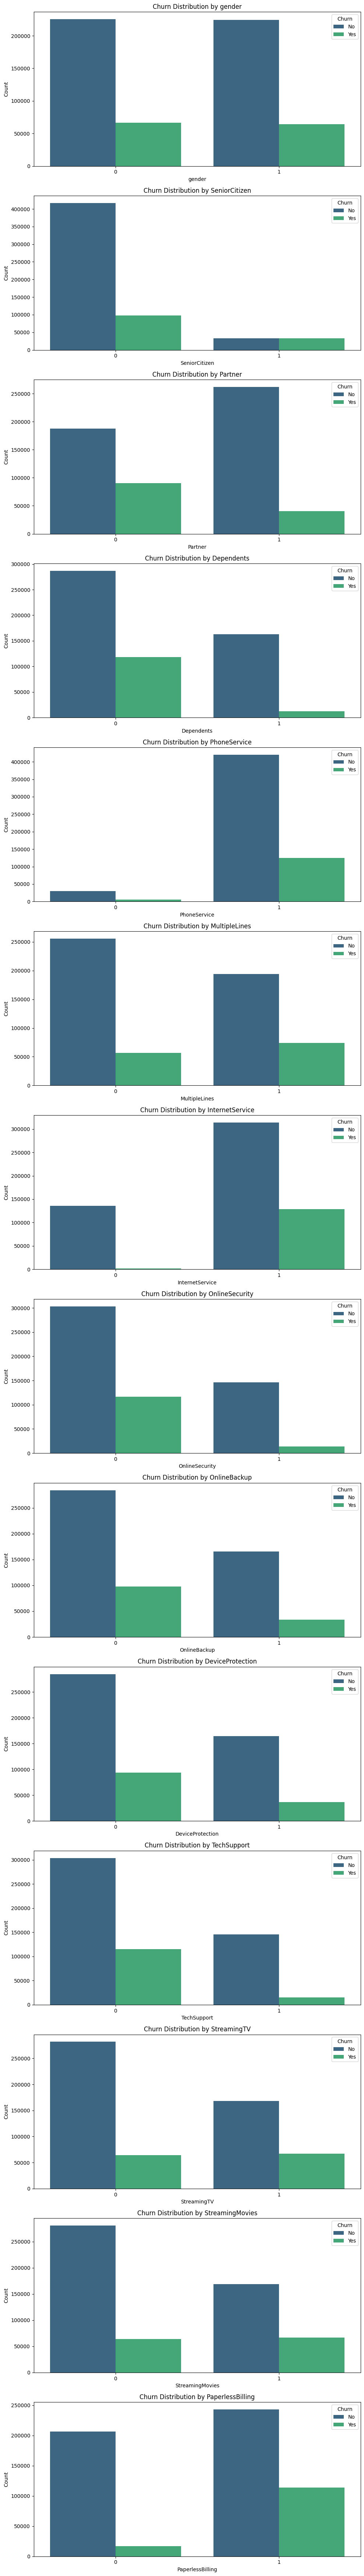

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

binary_columns = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling'
]

# Create a figure with subplots
fig, axes = plt.subplots(nrows=len(binary_columns), ncols=1, figsize=(10, 5 * len(binary_columns)))

# Iterate through each binary column and create a countplot
for i, col in enumerate(binary_columns):
    sns.countplot(data=train_df, x=col, hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Churn', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

In [158]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model
model = LogisticRegression(max_iter=5000) # Increased max_iter to help with convergence

# Define X_train and y_train
# X_train should not include 'id' as it's an identifier, not a feature
X_train = train_df.drop(['Churn', 'id'], axis=1)
y_train = train_df['Churn']

# Fit the model to your training data
model.fit(X_train, y_train)

# Prepare X_test for prediction: ensure it has the same columns as X_train
# X_test_processed already has 'id' column, but we drop it for prediction features
test_feature_columns = X_train.columns # Get the exact feature columns used for training
X_test_for_prediction = test_df[test_feature_columns] # Select only these features from test_df

# Make predictions
predictions = model.predict(X_test_for_prediction)

# Get churn probabilities for the test set
churn_probabilities = model.predict_proba(X_test_for_prediction)[:, 1] # Probability of class 1 (churn)

# Get churn probabilities for the training set (needed for ROC AUC on training data)
train_churn_probabilities = model.predict_proba(X_train)[:, 1]

# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'id': test_df['id'], # Use id from the original test_df
    'Predicted_Churn': predictions,
    'Churn_Probability': churn_probabilities
})

print("First 5 rows of the prediction results:")
display(results_df.head())

First 5 rows of the prediction results:


,id,Predicted_Churn,Churn_Probability
580434,594194,0.0,0.053752
580435,594195,0.0,0.000209
580436,594196,0.0,0.127772
580437,594197,0.0,0.003512
580438,594198,0.0,0.461440


ROC AUC Score on Training Data: 0.9077


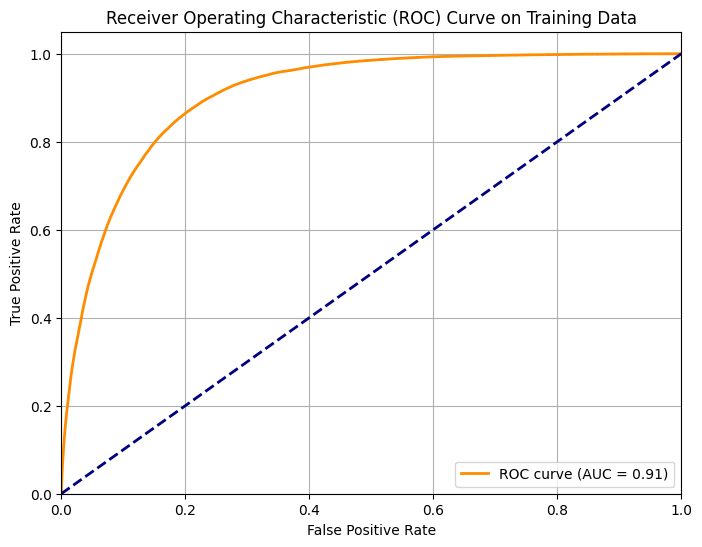

In [159]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC score on training data
# y_train contains the true labels
# train_churn_probabilities contains the predicted probabilities for the training data

# Ensure y_train and train_churn_probabilities are available
# If not, you might need to re-run the model fitting cell and the cell that generates train_churn_probabilities

if 'y_train' in locals() and 'train_churn_probabilities' in locals():
    fpr, tpr, thresholds = roc_curve(y_train, train_churn_probabilities)
    roc_auc = roc_auc_score(y_train, train_churn_probabilities)

    print(f"ROC AUC Score on Training Data: {roc_auc:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve on Training Data')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
else:
    print("Error: y_train or train_churn_probabilities not found. Please ensure the model fitting and training prediction steps were executed.")

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure predictions and churn_probabilities are available (they were created in cell 7O6dQkIfhWCP)
# If these variables are not available, you might need to re-run cell 7O6dQkIfhWCP

# Get the churn probabilities for the test set using the clean processed test features
# Use X_test_for_prediction which has the correct features for the model
churn_probabilities = model.predict_proba(X_test_for_prediction)[:, 1] # Probability of class 1 (churn)

# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'id': test_df['id'], # Use id from the original test_df
    'Predicted_Churn': predictions,
    'Churn_Probability': churn_probabilities
})

print("First 5 rows of the prediction results:")
display(results_df.head())

First 5 rows of the prediction results:


,id,Predicted_Churn,Churn_Probability
580434,594194,0.0,0.053752
580435,594195,0.0,0.000209
580436,594196,0.0,0.127772
580437,594197,0.0,0.003512
580438,594198,0.0,0.461440


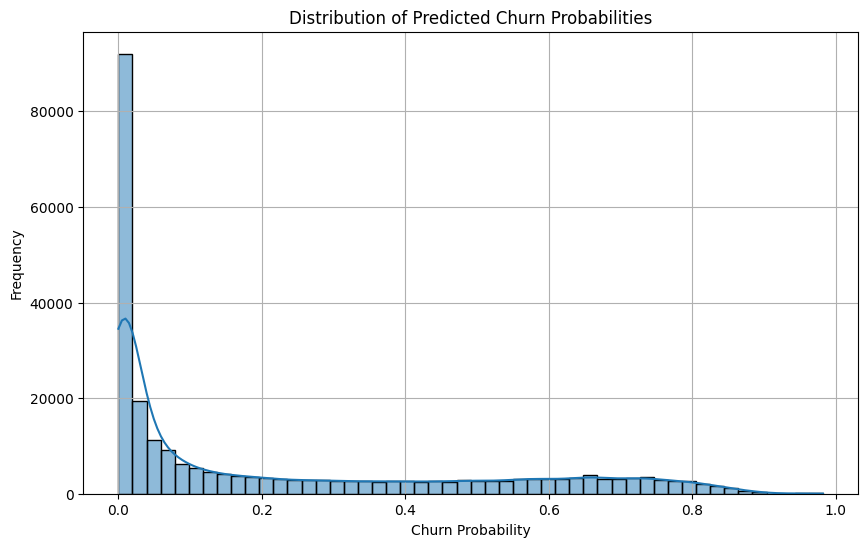

In [161]:
# Plot the distribution of churn probabilities
plt.figure(figsize=(10, 6))
sns.histplot(results_df['Churn_Probability'], bins=50, kde=True)
plt.title('Distribution of Predicted Churn Probabilities')
plt.xlabel('Churn Probability')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

To calculate the Area Under the Receiver Operating Characteristic (ROC) Curve, we need the true labels (`Churn` values) for the test set, in addition to the predicted probabilities. Since the `test_df` does not contain a `Churn` column, we cannot compute the ROC AUC for this test set. The ROC AUC score previously calculated was on the *training* data, which helps to understand the model's performance on data it has already seen, but it's not a reliable indicator of performance on unseen data.

Feature Selection

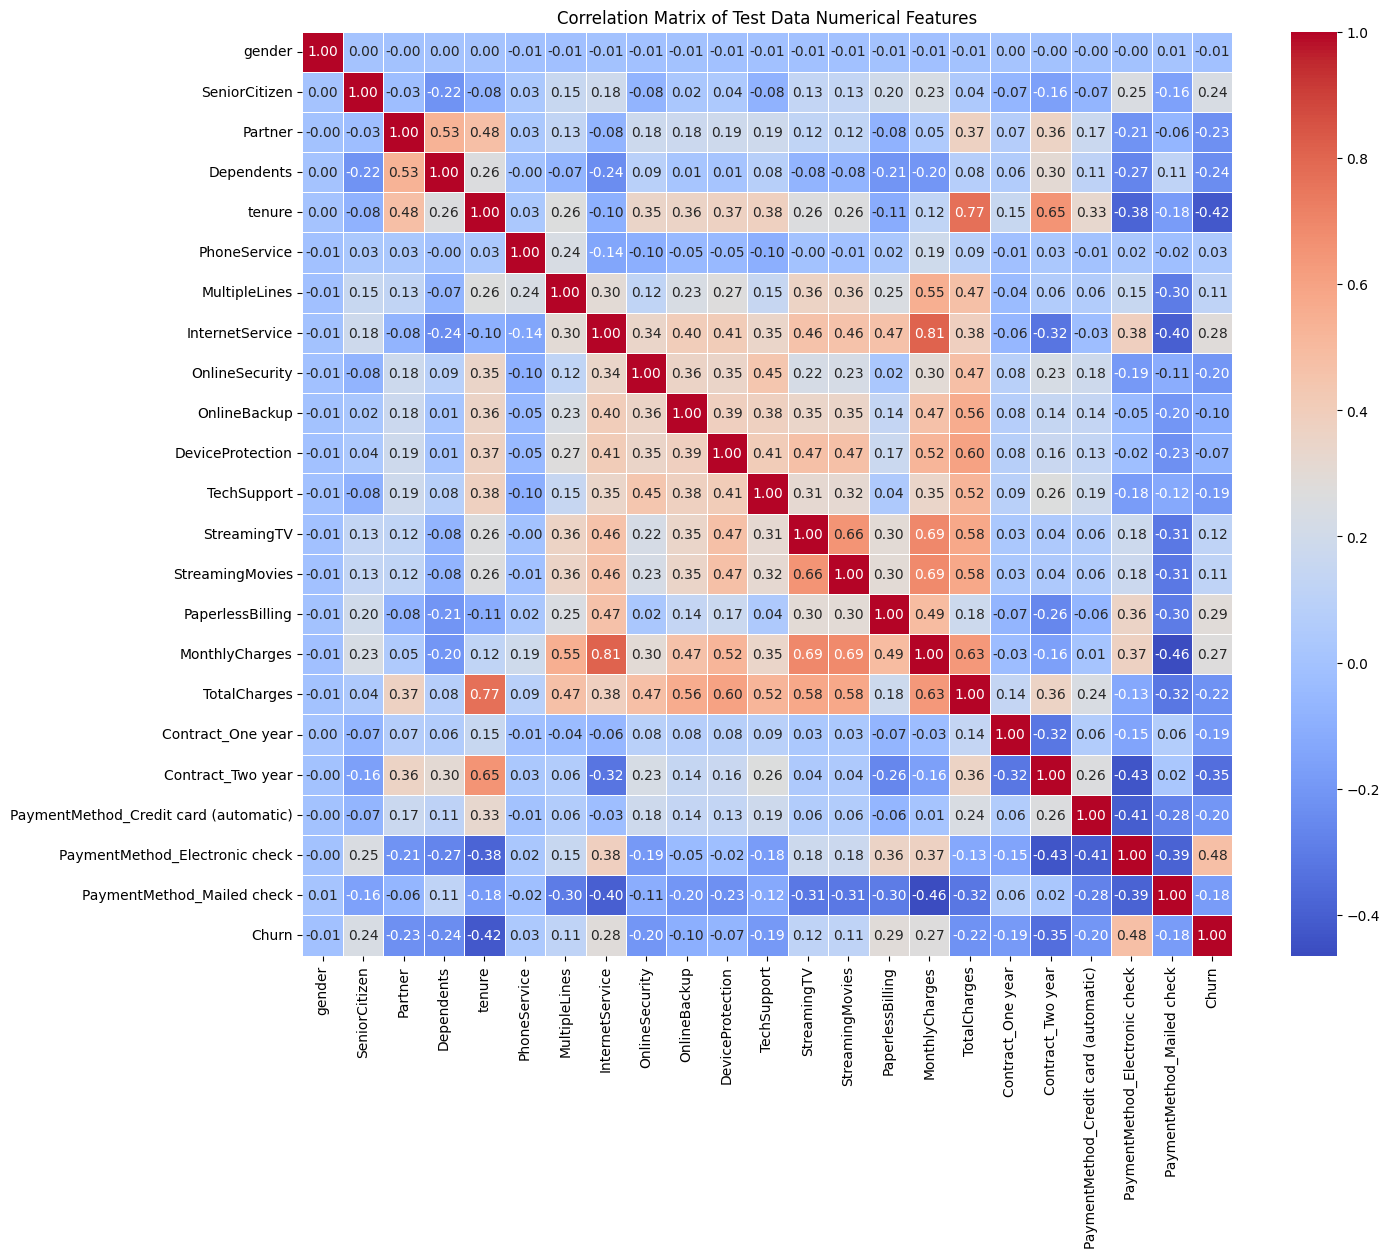

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the 'id' column before calculating correlation as it's an identifier
train_numerical_df = train_df.drop('id', axis=1)

# Calculate the correlation matrix
correlation_matrix = train_numerical_df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Test Data Numerical Features')
plt.show()

**Univariate Seletions with ANOVA testing. **

Top 10 Features

In [163]:
from sklearn.feature_selection import SelectKBest, f_regression

# Assuming df is your DataFrame and 'target_variable' is the column you want to predict
X = train_df.drop("Churn", axis=1)
y = train_df["Churn"]

# Applying SelectKBest with ANOVA F-value to get the top 10 features
selector = SelectKBest(score_func=f_regression, k=15)
selector.fit(X, y)

# Get the indices of the selected features
selected_features_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_features = X.columns[selected_features_indices]

# Displaying scores for each feature (for the selected top 10)
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
print("Top 10 Features based on F-scores:")
print(feature_scores.sort_values(by='Score', ascending=False).head(15))

Top 10 Features based on F-scores:
                                  Feature          Score
21         PaymentMethod_Electronic check  170437.964418
5                                  tenure  123326.313919
19                      Contract_Two year   80681.345833
15                       PaperlessBilling   51372.247357
8                         InternetService   49945.692409
16                         MonthlyCharges   46714.657653
4                              Dependents   35705.655617
2                           SeniorCitizen   34540.459045
3                                 Partner   31946.901015
17                           TotalCharges   29121.543486
9                          OnlineSecurity   25413.171871
20  PaymentMethod_Credit card (automatic)   24564.101910
12                            TechSupport   22028.048919
18                      Contract_One year   21629.017817
22             PaymentMethod_Mailed check   19137.602126


In [164]:
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model
model_top_features = LogisticRegression(max_iter=5000) # Increased max_iter to help with convergence

# Ensure 'id' is not in selected_features if it accidentally got there during feature selection
if 'id' in selected_features:
    selected_features = selected_features.drop('id')

# Define X_train and y_train using only the selected features
X_train_top_features = train_df[selected_features]
y_train = train_df['Churn']

# Fit the model to your training data with selected features
model_top_features.fit(X_train_top_features, y_train)

# Prepare X_test for prediction: ensure it has the same columns as X_train
X_test_for_prediction_top_features = test_df[selected_features] # Select only these features from test_df

# Make predictions
predictions_top_features = model_top_features.predict(X_test_for_prediction_top_features)

# Get churn probabilities
churn_probabilities_top_features = model_top_features.predict_proba(X_test_for_prediction_top_features)[:, 1] # Probability of class 1 (churn)

# Create a DataFrame to store the results
results_df_top_features = pd.DataFrame({
    'id': test_df['id'], # Use id from the original test_df
    'Predicted_Churn': predictions_top_features,
    'Churn_Probability': churn_probabilities_top_features
})

print("First 5 rows of the prediction results using top 10 features model:")
display(results_df_top_features.head())

# Also generate training churn probabilities for ROC AUC if needed
train_churn_probabilities_top_features = model_top_features.predict_proba(X_train_top_features)[:, 1]

First 5 rows of the prediction results using top 10 features model:


,id,Predicted_Churn,Churn_Probability
580434,594194,0.0,0.054090
580435,594195,0.0,0.000202
580436,594196,0.0,0.190462
580437,594197,0.0,0.003339
580438,594198,0.0,0.426832


ROC AUC Score on Training Data (Top Features Model): 0.9056


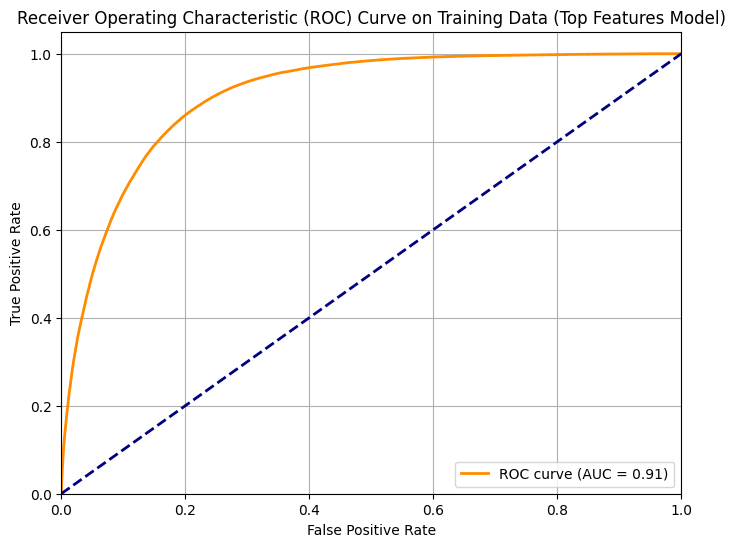

In [165]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC score on training data for the model with top features
# y_train contains the true labels
# train_churn_probabilities_top_features contains the predicted probabilities for the training data from the top features model

# Ensure y_train and train_churn_probabilities_top_features are available
# If not, you might need to re-run the model fitting cell and the cell that generates train_churn_probabilities_top_features

if 'y_train' in locals() and 'train_churn_probabilities_top_features' in locals():
    fpr_top_features, tpr_top_features, thresholds_top_features = roc_curve(y_train, train_churn_probabilities_top_features)
    roc_auc_top_features = roc_auc_score(y_train, train_churn_probabilities_top_features)

    print(f"ROC AUC Score on Training Data (Top Features Model): {roc_auc_top_features:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_top_features, tpr_top_features, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_top_features:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve on Training Data (Top Features Model)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
else:
    print("Error: y_train or train_churn_probabilities_top_features not found. Please ensure the model fitting and training prediction steps were executed.")

Top 5 Features

In [166]:
from sklearn.feature_selection import SelectKBest, f_regression

# Assuming df is your DataFrame and 'target_variable' is the column you want to predict
X = train_df.drop("Churn", axis=1)
y = train_df["Churn"]

# Applying SelectKBest with ANOVA F-value to get the top 5 features
selector = SelectKBest(score_func=f_regression, k=5)
selector.fit(X, y)

# Get the indices of the selected features
selected_features_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_features5 = X.columns[selected_features_indices]

# Displaying scores for each feature (for the selected top 10)
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
print("Top 10 Features based on F-scores:")
print(feature_scores.sort_values(by='Score', ascending=False).head(10))

Top 10 Features based on F-scores:
                           Feature          Score
21  PaymentMethod_Electronic check  170437.964418
5                           tenure  123326.313919
19               Contract_Two year   80681.345833
15                PaperlessBilling   51372.247357
8                  InternetService   49945.692409
16                  MonthlyCharges   46714.657653
4                       Dependents   35705.655617
2                    SeniorCitizen   34540.459045
3                          Partner   31946.901015
17                    TotalCharges   29121.543486


In [167]:
# Create a logistic regression model for top 5 features
model_top_5_features = LogisticRegression(max_iter=5000) # Increased max_iter to help with convergence

# Ensure 'id' is not in selected_features5 if it accidentally got there during feature selection
current_selected_features_5 = selected_features5.copy() # Make a copy to avoid modifying original Series/Index
if 'id' in current_selected_features_5:
    current_selected_features_5 = current_selected_features_5.drop('id')

# Define X_train and y_train using only the selected top 5 features
X_train_top_5_features = train_df[current_selected_features_5]
y_train = train_df['Churn']

# Fit the model to your training data with selected features
model_top_5_features.fit(X_train_top_5_features, y_train)

# Prepare X_test for prediction: ensure it has the same columns as X_train
X_test_for_prediction_top_5_features = test_df[current_selected_features_5] # Select only these features from test_df

# Make predictions
predictions_top_5_features = model_top_5_features.predict(X_test_for_prediction_top_5_features)

# Get churn probabilities
churn_probabilities_top_5_features = model_top_5_features.predict_proba(X_test_for_prediction_top_5_features)[:, 1] # Probability of class 1 (churn)

# Create a DataFrame to store the results
results_df_top_5_features = pd.DataFrame({
    'id': test_df['id'], # Use id from the original test_df
    'Predicted_Churn': predictions_top_5_features,
    'Churn_Probability': churn_probabilities_top_5_features
})

print("First 5 rows of the prediction results using top 5 features model:")
display(results_df_top_5_features.head())

# Also generate training churn probabilities for ROC AUC if needed
train_churn_probabilities_top_5_features = model_top_5_features.predict_proba(X_train_top_5_features)[:, 1]

First 5 rows of the prediction results using top 5 features model:


,id,Predicted_Churn,Churn_Probability
580434,594194,0.0,0.044619
580435,594195,0.0,0.000709
580436,594196,0.0,0.318629
580437,594197,0.0,0.005283
580438,594198,0.0,0.387614


ROC AUC Score on Training Data (Top 5 Features Model): 0.8845


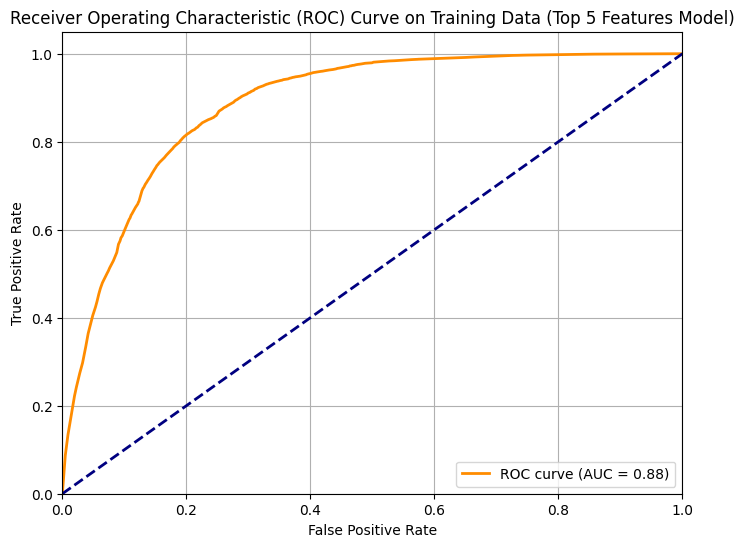

In [168]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC score on training data for the model with top 5 features
# y_train contains the true labels
# train_churn_probabilities_top_5_features contains the predicted probabilities for the training data from the top 5 features model

# Ensure y_train and train_churn_probabilities_top_5_features are available
# If not, you might need to re-run the model fitting cell and the cell that generates train_churn_probabilities_top_5_features

if 'y_train' in locals() and 'train_churn_probabilities_top_5_features' in locals():
    fpr_top_5_features, tpr_top_5_features, thresholds_top_5_features = roc_curve(y_train, train_churn_probabilities_top_5_features)
    roc_auc_top_5_features = roc_auc_score(y_train, train_churn_probabilities_top_5_features)

    print(f"ROC AUC Score on Training Data (Top 5 Features Model): {roc_auc_top_5_features:.4f}")

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_top_5_features, tpr_top_5_features, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_top_5_features:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve on Training Data (Top 5 Features Model)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
else:
    print("Error: y_train or train_churn_probabilities_top_5_features not found. Please ensure the model fitting and training prediction steps were executed.")

In [169]:
from sklearn.linear_model import LogisticRegression

# Prepare X_train and y_train
X_train_lasso = train_df.drop(['Churn', 'id'], axis=1)
y_train_lasso = train_df['Churn']

# Initialize Logistic Regression with L1 penalty (LASSO) and a suitable solver
# C is the inverse of regularization strength; smaller values specify stronger regularization.
lasso_model = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=10000) # Increased max_iter

# Fit the model
lasso_model.fit(X_train_lasso, y_train_lasso)

# Get the coefficients
coefficients = pd.DataFrame({
    'Feature': X_train_lasso.columns,
    'Coefficient': lasso_model.coef_[0]
})

# Filter for non-zero coefficients (selected features)
selected_features_lasso = coefficients[coefficients['Coefficient'] != 0]

print("Features selected by LASSO with non-zero coefficients:")
display(selected_features_lasso.sort_values(by='Coefficient', ascending=False))

Features selected by LASSO with non-zero coefficients:


,Feature,Coefficient
20,PaymentMethod_Electronic check,0.539001
1,SeniorCitizen,0.423658
14,PaperlessBilling,0.286734
6,MultipleLines,0.274804
12,StreamingTV,0.168208
13,StreamingMovies,0.153622
15,MonthlyCharges,0.020233
16,TotalCharges,0.000513
7,InternetService,-0.069252
2,Partner,-0.090603


### Evaluating the LASSO Model

ROC AUC Score on Training Data (LASSO Model): 0.9042


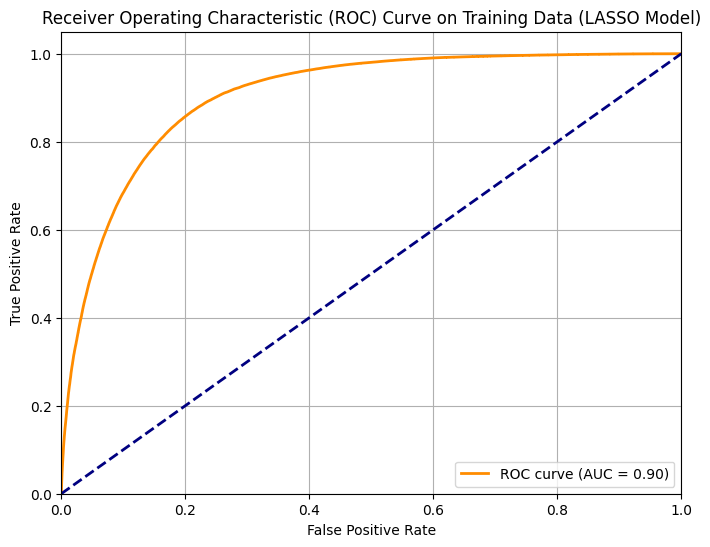

In [170]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities on the training data using the LASSO model
train_churn_probabilities_lasso = lasso_model.predict_proba(X_train_lasso)[:, 1]

# Calculate ROC AUC score on training data
roc_auc_lasso = roc_auc_score(y_train_lasso, train_churn_probabilities_lasso)
print(f"ROC AUC Score on Training Data (LASSO Model): {roc_auc_lasso:.4f}")

# Plot ROC curve
fpr_lasso, tpr_lasso, _ = roc_curve(y_train_lasso, train_churn_probabilities_lasso)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso, tpr_lasso, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lasso:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Training Data (LASSO Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Making Predictions with the LASSO Model

In [171]:
# Prepare X_test for prediction using only the features selected by LASSO
# Ensure 'id' is dropped from test_df as well
X_test_lasso = test_df[selected_features_lasso['Feature']]

# Make predictions with the LASSO model
predictions_lasso = lasso_model.predict(X_test_lasso)
churn_probabilities_lasso = lasso_model.predict_proba(X_test_lasso)[:, 1]

# Create a DataFrame to store the results
results_df_lasso = pd.DataFrame({
    'id': test_df['id'],
    'Predicted_Churn': predictions_lasso,
    'Churn_Probability': churn_probabilities_lasso
})

print("First 5 rows of prediction results using LASSO selected features:")
display(results_df_lasso.head())

First 5 rows of prediction results using LASSO selected features:


,id,Predicted_Churn,Churn_Probability
580434,594194,0.0,0.099147
580435,594195,0.0,0.000513
580436,594196,0.0,0.172098
580437,594197,0.0,0.007287
580438,594198,1.0,0.510866


In [194]:
# Create the submission DataFrame with 'id' and 'Churn_Probability'
submission_df_lasso = results_df_lasso[['id', 'Churn_Probability']].copy()

# Rename 'Churn_Probability' to 'Churn' as requested for the output file
submission_df_lasso.rename(columns={'Churn_Probability': 'Churn'}, inplace=True)

# Save the DataFrame to a CSV file without the index
submission_df_lasso.to_csv('lasso_predictions.csv', index=False)

print("Output file 'lasso_predictions.csv' created successfully with 'id' and 'Churn' (churn probability).")
print("First 5 rows of the submission file:")
display(submission_df_lasso.head())

Output file 'lasso_predictions.csv' created successfully with 'id' and 'Churn' (churn probability).
First 5 rows of the submission file:


,id,Churn
580434,594194,0.099147
580435,594195,0.000513
580436,594196,0.172098
580437,594197,0.007287
580438,594198,0.510866


In [195]:
# Create the submission DataFrame with 'id' and 'Churn_Probability' for the regular Logistic Regression model
submission_df_logistic = results_df[['id', 'Churn_Probability']].copy()

# Rename 'Churn_Probability' to 'Churn' as requested for the output file
submission_df_logistic.rename(columns={'Churn_Probability': 'Churn'}, inplace=True)

# Save the DataFrame to a CSV file without the index
submission_df_logistic.to_csv('logistic_regression_predictions.csv', index=False)

print("Output file 'logistic_regression_predictions.csv' created successfully with 'id' and 'Churn' (churn probability).")
print("First 5 rows of the submission file:")
display(submission_df_logistic.head())

Output file 'logistic_regression_predictions.csv' created successfully with 'id' and 'Churn' (churn probability).
First 5 rows of the submission file:


,id,Churn
580434,594194,0.053752
580435,594195,0.000209
580436,594196,0.127772
580437,594197,0.003512
580438,594198,0.461440
